In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install roboflow

from roboflow import Roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0,

In [3]:
!rm -rf /kaggle/working/*

In [4]:
rf = Roboflow(api_key="jdzJB4T1KIqIaMi8j1MJ")
project = rf.workspace("nandini-verma-pjadq").project("missile-detection-kj6oz")
version = project.version(3)
dataset = version.download("yolov12")
                
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Missile-Detection-3 in yolov12:: 100%|██████████| 1473/1473 [00:00<00:00, 9867.11it/s]


In [5]:
test_image= '/kaggle/working/Missile-Detection-3/test/images'
train_image= '/kaggle/working/Missile-Detection-3/train/images'
valid_image= '/kaggle/working/Missile-Detection-3/valid/images'

In [6]:
print('test images: ', len(os.listdir(test_image)))
print('train images: ', len(os.listdir(train_image)))
print('valid images: ', len(os.listdir(valid_image)))

test images:  104
train images:  554
valid images:  76


In [7]:
# ============================================================
# YOLOv12 Missile Detection - Kaggle Notebook
# ============================================================

# ── 1. INSTALL DEPENDENCIES ──────────────────────────────────
!pip install ultralytics roboflow albumentations opencv-python-headless -q
!pip install supervision -q  # for visualization

import os, shutil, random, yaml, cv2
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO
import supervision as sv

# ── 2. ROBOFLOW DATASET IMPORT ───────────────────────────────
from roboflow import Roboflow


DATASET_DIR = Path(dataset.location)
print(f"Dataset at: {DATASET_DIR}")
print("Contents:", list(DATASET_DIR.iterdir()))

# ── 3. DATASET AUDIT ─────────────────────────────────────────
def audit_dataset(dataset_dir):
    """Analyze dataset before training — critical step."""
    stats = {}
    for split in ['train', 'valid', 'test']:
        img_dir = dataset_dir / split / 'images'
        lbl_dir = dataset_dir / split / 'labels'
        
        if not img_dir.exists():
            continue
            
        images = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
        labels = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
        
        # Count background images (empty label files)
        background_count = 0
        bbox_sizes = []
        for lbl in labels:
            content = lbl.read_text().strip()
            if not content:
                background_count += 1
            else:
                for line in content.split('\n'):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        w, h = float(parts[3]), float(parts[4])
                        bbox_sizes.append((w, h))
        
        stats[split] = {
            'images': len(images),
            'labels': len(labels),
            'background': background_count,
            'with_objects': len(labels) - background_count,
            'avg_bbox': np.mean(bbox_sizes, axis=0).tolist() if bbox_sizes else [0, 0]
        }
    
    print("\n📊 DATASET AUDIT:")
    print("="*50)
    for split, s in stats.items():
        print(f"\n{split.upper()}:")
        print(f"  Images:      {s['images']}")
        print(f"  With objects:{s['with_objects']}")
        print(f"  Background:  {s['background']}")
        print(f"  Avg BBox W×H:{s['avg_bbox'][0]:.3f} × {s['avg_bbox'][1]:.3f} (normalized)")
    
    return stats

stats = audit_dataset(DATASET_DIR)

# ── 4. AUGMENTATION PIPELINE ─────────────────────────────────
# Designed specifically for missile detection:
# - Handles high-aspect-ratio objects (long, thin)
# - Simulates real-world sensor conditions

def get_augmentation_pipeline(image_size=640):
    """
    Heavy augmentation pipeline for missile detection.
    Albumentations handles bbox transformation automatically.
    """
    return A.Compose([
        # Spatial transforms — careful with thin objects
        A.RandomRotate90(p=0.3),
        A.Rotate(limit=35, border_mode=cv2.BORDER_REFLECT_101, p=0.6),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.ShiftScaleRotate(
            shift_limit=0.1, scale_limit=0.3, rotate_limit=20,
            border_mode=cv2.BORDER_REFLECT_101, p=0.6
        ),
        
        # Perspective/distortion (simulates different camera angles)
        A.Perspective(scale=(0.02, 0.08), p=0.3),
        A.ElasticTransform(alpha=1, sigma=10, p=0.2),
        
        # Color/exposure transforms (sensor variance)
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=40, val_shift_limit=30),
        ], p=0.8),
        
        # Simulate atmospheric/sensor noise
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 80.0)),
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5)),
            A.MultiplicativeNoise(multiplier=(0.8, 1.2)),
        ], p=0.5),
        
        # Blur (motion blur = missile moving fast!)
        A.OneOf([
            A.MotionBlur(blur_limit=(3, 9)),   # missile motion
            A.GaussianBlur(blur_limit=(3, 7)),  # defocus
        ], p=0.4),
        
        # Occlusion robustness
        A.CoarseDropout(
            num_holes_range=(1, 6),
            hole_height_range=(10, 40),
            hole_width_range=(10, 40),
            fill=0, p=0.4
        ),
        
        # Weather simulation
        A.OneOf([
            A.RandomFog(fog_coef_range=(0.1, 0.3), p=1.0),
            A.RandomShadow(p=1.0),
        ], p=0.2),
        
        # Final resize
        A.Resize(image_size, image_size),
        
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.3,       # drop bbox if <30% visible after crop
        filter_invalid_bboxes=True
    ))


def augment_split(split_dir, output_dir, target_count, image_size=640, aug_pipeline=None):
    """
    Augment a dataset split to reach target_count images.
    Handles both labeled images and background images correctly.
    """
    img_dir = Path(split_dir) / 'images'
    lbl_dir = Path(split_dir) / 'labels'
    out_img_dir = Path(output_dir) / 'images'
    out_lbl_dir = Path(output_dir) / 'labels'
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)
    
    if aug_pipeline is None:
        aug_pipeline = get_augmentation_pipeline(image_size)
    
    images = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    
    # Copy originals first
    for img_path in images:
        shutil.copy(img_path, out_img_dir / img_path.name)
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            shutil.copy(lbl_path, out_lbl_dir / (img_path.stem + '.txt'))
        else:
            # Create empty label file for background images
            (out_lbl_dir / (img_path.stem + '.txt')).touch()
    
    current_count = len(images)
    aug_idx = 0
    
    print(f"\nAugmenting {split_dir.split('/')[-1]}: {current_count} → {target_count}")
    
    while current_count < target_count:
        # Sample an image (bias toward object images, not backgrounds)
        img_path = random.choice(images)
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        
        # Read image
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        # Read labels
        bboxes, class_labels = [], []
        if lbl_path.exists():
            content = lbl_path.read_text().strip()
            if content:
                for line in content.split('\n'):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_labels.append(int(parts[0]))
                        # YOLO format: cx, cy, w, h (normalized)
                        bboxes.append([float(p) for p in parts[1:]])
        
        # Apply augmentation
        try:
            augmented = aug_pipeline(
                image=image,
                bboxes=bboxes,
                class_labels=class_labels
            )
        except Exception as e:
            continue
        
        aug_image = augmented['image']
        aug_bboxes = augmented['bboxes']
        aug_labels = augmented['class_labels']
        
        # Save augmented image
        aug_name = f"aug_{aug_idx:06d}"
        aug_img_path = out_img_dir / f"{aug_name}.jpg"
        cv2.imwrite(
            str(aug_img_path),
            cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR),
            [cv2.IMWRITE_JPEG_QUALITY, 95]
        )
        
        # Save augmented labels
        aug_lbl_path = out_lbl_dir / f"{aug_name}.txt"
        with open(aug_lbl_path, 'w') as f:
            for cls, bbox in zip(aug_labels, aug_bboxes):
                cx, cy, bw, bh = bbox
                # Clamp to valid range
                cx = max(0.001, min(0.999, cx))
                cy = max(0.001, min(0.999, cy))
                bw = max(0.001, min(0.999, bw))
                bh = max(0.001, min(0.999, bh))
                f.write(f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
        
        aug_idx += 1
        current_count += 1
        
        if current_count % 200 == 0:
            print(f"  Progress: {current_count}/{target_count}")
    
    print(f"  ✅ Done: {current_count} images in {output_dir}")
    return current_count


# ── 5. RUN AUGMENTATION ──────────────────────────────────────
AUG_DATASET_DIR = Path('/kaggle/working/missile_augmented')
IMAGE_SIZE = 640
aug_pipeline = get_augmentation_pipeline(IMAGE_SIZE)

# Target distribution — keep val/test clean (no augmentation!)
augment_split(
    str(DATASET_DIR / 'train'),
    str(AUG_DATASET_DIR / 'train'),
    target_count=4500,           # 730 * ~6x augmentation
    image_size=IMAGE_SIZE,
    aug_pipeline=aug_pipeline
)

# Val and test: copy as-is (NEVER augment eval sets)
for split in ['valid', 'test']:
    src = DATASET_DIR / split
    dst = AUG_DATASET_DIR / split
    if src.exists():
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✅ Copied {split} as-is")


# ── 6. CREATE data.yaml ──────────────────────────────────────
data_yaml = {
    'path': str(AUG_DATASET_DIR),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['missile']
}



# Read the original Roboflow yaml
original_yaml_path = DATASET_DIR / 'data.yaml'
with open(original_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Original yaml contents:")
print(data_config)  # Check what Roboflow gave you — nc, names, paths

# Just update the path to point to augmented directory
data_config['path'] = str(AUG_DATASET_DIR)

yaml_path = AUG_DATASET_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("\nUpdated yaml:")
print(data_config)


# ── 7. YOLOV12 TRAINING ──────────────────────────────────────
# YOLOv12 uses same Ultralytics interface as v8/v11



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

  Progress: 600/4500
  Progress: 800/4500
  Progress: 1000/4500
  Progress: 1200/4500
  Progress: 1400/4500
  Progress: 1600/4500
  Progress: 1800/4500
  Progress: 2000/4500
  Progress: 2200/4500
  Progress: 2400/4500
  Progress: 2600/4500
  Progress: 2800/4500
  Progress: 3000/4500
  Progress: 3200/4500
  Progress: 3400/4500
  Progress: 3600/4500
  Progress: 3800/4500
  Progress: 4000/4500
  Progress: 4200/4500
  Progress: 4400/4500
  ✅ Done: 4500 images in /kaggle/working/missile_augmented/train
✅ Copied valid as-is
✅ Copied test as-is
Original yaml contents:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['Missile'], 'roboflow': {'workspace': 'nandini-verma-pjadq', 'project': 'missile-detection-kj6oz', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/nandini-verma-pjadq/missile-detection-kj6oz/dataset/3'}}

Updated yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc'

In [8]:
# Run this in a new code cell in your Kaggle notebook to download the weights
!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11s.pt


--2026-06-14 14:55:49--  https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11s.pt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/1c11d5fd-cb03-4cf0-9eb2-0b0f5601ef45?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-14T15%3A41%3A48Z&rscd=attachment%3B+filename%3Dyolo11s.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-14T14%3A41%3A01Z&ske=2026-06-14T15%3A41%3A48Z&sks=b&skv=2018-11-09&sig=AIfY5DLjDm%2FkRCjMHWBoJ4lDWlxX8CAnZk5You1xI6A%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MTQ1MDc0OSwibmJmIjoxNzgxNDQ4OTQ5LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=9, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.3, cls_pw=0.0, compile=False, conf=None, copy_paste=0.4, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/missile_augmented/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=True, name=missile_yolo

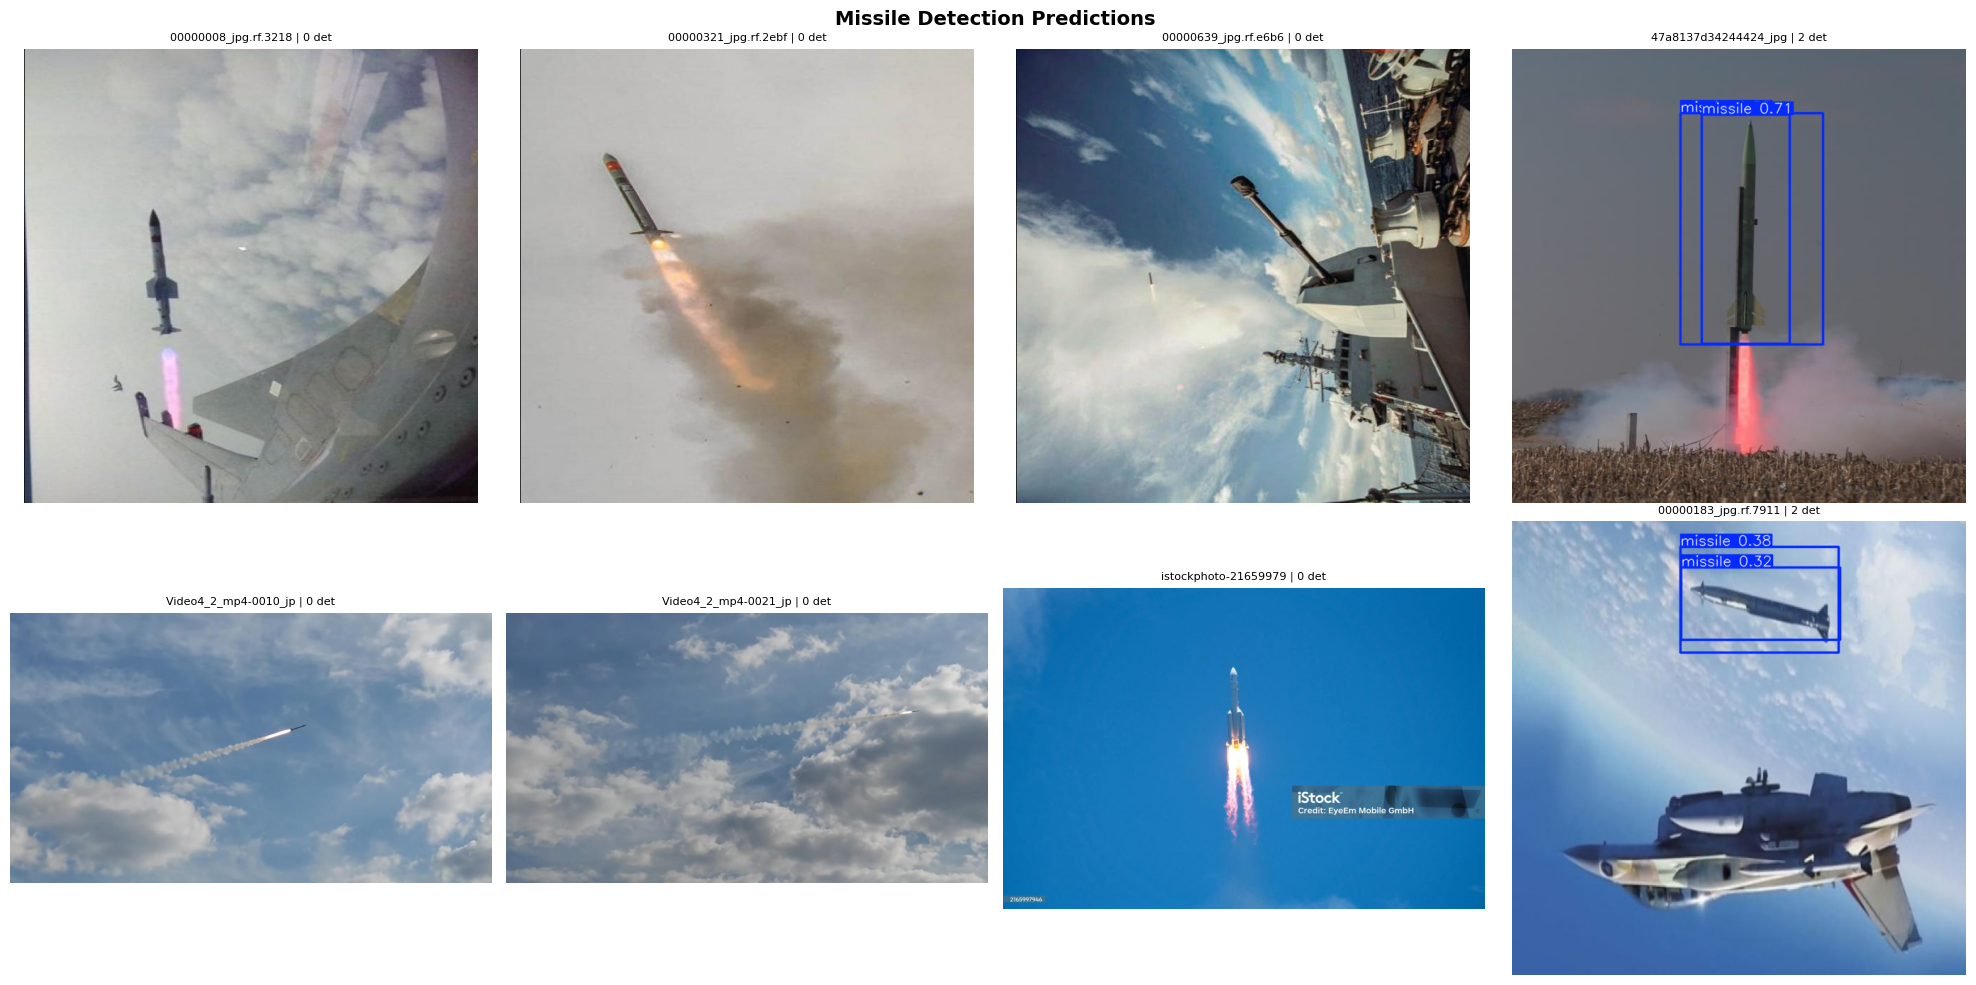

Saved predictions_grid.png
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/missile_yolov12/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (18.3 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 332ms
 Downloaded onnxruntime
Prepared 2 packages in 291ms
Installed 2 packages in 12ms
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.3s, saved as '/kaggle/working/run

In [9]:
model = YOLO('yolo11s.pt')  # Start with Small; upgrade to 'm' if GPU allows

# Critical hyperparameters explained below
results = model.train(
    data=str(yaml_path),
    
    # ── Core ──────────────────────────────────────────────
    epochs=3,              # More epochs for small dataset
    imgsz=IMAGE_SIZE,        # 640 standard; try 1280 if GPU allows
    batch=16,                # Reduce to 8 if OOM on Kaggle P100
    
    # ── Augmentation (Ultralytics built-in ON TOP of yours) ──
    mosaic=1.0,              # Always ON for small datasets
    copy_paste=0.4,          # Self-paste missiles into backgrounds           
    flipud=0.3,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    
    # ── Optimizer ─────────────────────────────────────────
    optimizer='AdamW',       # Better than SGD for small datasets
    lr0=0.001,               # Initial LR
    lrf=0.01,                # Final LR = lr0 * lrf
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5,         # Warmup critical for stability
    warmup_momentum=0.8,
    
    # ── Loss weights — tuned for single-class detection ───
    box=9,
    cls=0.3,                 # Low cls weight (only 1 class)
    dfl=1.5,
    
    # ── Regularization ────────────────────────────────────
    dropout=0.1,             # Helps with small datasets
    label_smoothing=0.05,     # Prevents overconfidence
    
    # ── Training config ───────────────────────────────────
    patience=30,             # Early stopping
    save_period=10,          # Save every 10 epochs
    val=True,
    plots=True,
    seed=42,
    
    # ── Kaggle paths ──────────────────────────────────────
    project='/kaggle/working/runs',
    name='missile_yolov12',
    exist_ok=True,
    
    # ── Pretrained (critical for small datasets!) ─────────
    pretrained=True,
    
    # ── Multi-scale training ──────────────────────────────
    multi_scale=True,        # Train at multiple resolutions
    
    # ── Close mosaic near end (standard trick) ────────────
    close_mosaic=20,         # Disable mosaic in last 15 epochs
)

print("\n✅ Training complete!")
print(f"Best mAP50: {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")


# ── 8. EVALUATION ────────────────────────────────────────────
best_model = YOLO('/kaggle/working/runs/missile_yolov12/weights/best.pt')

# Validate on test set
test_results = best_model.val(
    data=str(yaml_path),
    split='test',
    imgsz=IMAGE_SIZE,
    conf=0.25,
    iou=0.5,
    plots=True,
    save_json=True,
)

print("\n📊 TEST SET RESULTS:")
print(f"  mAP50:    {test_results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP50-95: {test_results.results_dict.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"  Precision:{test_results.results_dict.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall:   {test_results.results_dict.get('metrics/recall(B)', 0):.4f}")


# ── 9. INFERENCE VISUALIZATION ───────────────────────────────
def visualize_predictions(model, dataset_dir, split='test', n_samples=8, conf=0.25):
    """Visualize random predictions from a split."""
    img_dir = Path(dataset_dir) / split / 'images'
    images = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    samples = random.sample(images, min(n_samples, len(images)))
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for ax, img_path in zip(axes, samples):
        results = model(str(img_path), conf=conf, verbose=False)
        annotated = results[0].plot()
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        ax.imshow(annotated_rgb)
        
        n_det = len(results[0].boxes)
        ax.set_title(f"{img_path.name[:20]} | {n_det} det", fontsize=8)
        ax.axis('off')
    
    plt.suptitle('Missile Detection Predictions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/predictions_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved predictions_grid.png")

visualize_predictions(best_model, AUG_DATASET_DIR, split='test', conf=0.3)


# ── 10. EXPORT FOR DEPLOYMENT ────────────────────────────────
# Export to ONNX for inference outside Kaggle
best_model.export(format='onnx', imgsz=IMAGE_SIZE, simplify=True, dynamic=False)
print("✅ Exported to ONNX")

# Optional: TensorRT for GPU inference
# best_model.export(format='engine', imgsz=IMAGE_SIZE, half=True)